US Accidents (2016-2023)
- Full EDA analysis

QUESTION: What weather, time of day and road features best predict whether an accident will be severe so that authoroties can target warnings and resources where they matter most?

TARGET: To predict the SEVERITY of the accident (on a scale of 1-4) with regards to its effect on traffic in terms of delay 


In [2]:
import kagglehub
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print('path to dataset files:', path)

c:\Users\jagmeet\vsc\pypharm_eda\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


path to dataset files: C:\Users\jagmeet\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13


In [3]:
import pandas as pd 
import numpy as np 
import statistics as stats
import seaborn as sns 
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv(path + '/US_Accidents_March23.csv')


In [5]:
df.dtypes
df.info(show_counts=True)
# split data into numerical and cateogrical features 
num_cols = df.select_dtypes(include = 'number').columns.tolist()
cat_cols = df.select_dtypes(exclude= 'number').columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     7728394 non-null  str    
 1   Source                 7728394 non-null  str    
 2   Severity               7728394 non-null  int64  
 3   Start_Time             7728394 non-null  str    
 4   End_Time               7728394 non-null  str    
 5   Start_Lat              7728394 non-null  float64
 6   Start_Lng              7728394 non-null  float64
 7   End_Lat                4325632 non-null  float64
 8   End_Lng                4325632 non-null  float64
 9   Distance(mi)           7728394 non-null  float64
 10  Description            7728389 non-null  str    
 11  Street                 7717525 non-null  str    
 12  City                   7728141 non-null  str    
 13  County                 7728394 non-null  str    
 14  State                  772839

In [6]:
# Check how rows are indexed:
df.index
# range index - a row counter


RangeIndex(start=0, stop=7728394, step=1)

In [7]:
# check how much memory is saved before going into detail
shallow_memory = df.memory_usage(deep = False).sum()
deep_memory = df.memory_usage(deep = True).sum()
hidden = deep_memory - shallow_memory
pct_hidden = hidden / deep_memory * 100 # 78.94308031400918


SUMMARY AND DESCRIPTIVE STATISTICS:
numbers describing each column 
    measures of central tendancy 
    measures of spread 
    shape
    range
    skew check 



In [8]:
df.describe(include = 'number') # include numerical values 


,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


observe trends between 50%, 75% and max value.
distance/temp/windchill/visibility/windspeed/precipitation shows a large gap - potential outliers present 
Mean has not been pulled away from median - likely due to high density of points and extreme outliers being the minority 
Check if the volume of data 'masks' the outliers (99.99 % of 7.7 million columns - 770 rows)

In [9]:
df.describe(include = 'number', percentiles = [0.5, 0.75,0.99, 0.9999])


,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
99%,4.000000e+00,4.747886e+01,-7.148164e+01,4.727449e+01,-7.285381e+01,6.955000e+00,9.600000e+01,9.600000e+01,1.000000e+02,3.044000e+01,1.000000e+01,2.300000e+01,1.800000e-01
99.99%,4.000000e+00,4.887415e+01,-6.982946e+01,4.888346e+01,-6.962346e+01,4.918000e+01,1.110000e+02,1.110000e+02,1.000000e+02,3.082000e+01,7.000000e+01,4.300000e+01,2.545193e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


temperature, windchill, pressure, visibility, windspeed, precipitation the jump is large between 99.99% and max value - indicates outliers

distance - both the 99.99% and the max values show extreme values relative the mean and medians  - not safe to use mean 



In [10]:
# Determine which numerical columns require median use vs mean use 
def audit_cols(df):
    result=[]
    num_cols = df.select_dtypes(include = [np.number]).columns
    for col in num_cols:
        # calculate percentiles
        median, p75, p99_99 = df[col].quantile([0.5, 0.75, 0.9999])
        # mean, std, max
        mean, std, max = df[col].agg(['mean', 'std', 'max'])

        #determine if the mean is larger than 75% (already greater than median) - suggest possible outlier
        mean_greater_than_75 = mean > p75
        # cehck if there is a large gap between 99.99% and max 
        if p99_99>0:
            ratio = max / p99_99
        else:
            ratio = max if max > 0 else 1
        # ratio between mean and median 
        if median > 0:
            median_ratio = mean / median
        else:
            median_ratio = mean if mean > 0 else 1

        #decision making:
        if mean_greater_than_75 or ratio > 1.2 and ratio > 3:
            verdict = 'median must be used , mean is likely biased'
            reason = []
            if mean_greater_than_75: reason.append('mean is greater than 75%')
            if median_ratio > 1.2: reason.append(f"Mean is {median_ratio:.1f}x higher than Median")
            if ratio > 3: reason.append(f'max is {ratio:.1f}x higher than 99.99% percentile (Extreme Tail)')
            reason_str = ", ".join(reason)
        else:
            verdict = "Use MEAN (Safe)"
            reason_str = "Data is balanced and symmetric"
        result.append({'column': col, 'mean': mean, 'median': median, 'std': std, 'max': max, 'p75': p75, 'p99_99': p99_99, 'mean_greater_than_75': mean_greater_than_75, 'ratio_max_to_p99_99': ratio, 'median_ratio': median_ratio, 'verdict': verdict, 'reason': reason_str})
    return pd.DataFrame(result)

In [11]:
audit_report = audit_cols(df)
print(audit_report.to_string(index = False))


           column       mean     median       std         max        p75     p99_99  mean_greater_than_75  ratio_max_to_p99_99  median_ratio                                     verdict                                                                                                               reason
         Severity   2.212384   2.000000  0.487531    4.000000   2.000000   4.000000                  True             1.000000      1.106192 median must be used , mean is likely biased                                                                                             mean is greater than 75%
        Start_Lat  36.201195  35.823974  5.076079   49.002201  40.084959  48.874151                 False             1.002620      1.010530                             Use MEAN (Safe)                                                                                       Data is balanced and symmetric
        Start_Lng -94.702545 -87.766616 17.391756  -67.113167 -80.353676 -69.829456           

In [12]:
mean_cols = audit_report[audit_report.iloc[:, -1] == "Data is balanced and symmetric"] # all numericla columns where mean can be used 
median_cols = audit_report[audit_report.iloc[:, -1] != "Data is balanced and symmetric"] # all numerical columns where median should be used instead of mean
# observe further for anomalies in the data, especially for columns where median is recommended over mean.

Further explorign data SKEW & likelyhood of errors  
kurotosis - how heavy our tail of data is / how often extreme outliers occur 
    
    - </= 0 - flat 
    - >0 - heavy tail 
    - 0 = normal 

- round to 2 decimal places


In [13]:
round(df.select_dtypes(include = 'number').skew(), 2) # this tells us how skewed our numerical data is 
round(df.select_dtypes(include = 'number').kurtosis(), 2) # this tells us how heavy tailed our numerical data is


Severity                 3.30
Start_Lat               -0.53
Start_Lng               -1.36
End_Lat                 -0.56
End_Lng                 -1.56
Distance(mi)          1649.60
Temperature(F)          -0.00
Wind_Chill(F)            0.15
Humidity(%)             -0.72
Pressure(in)            21.84
Visibility(mi)          81.89
Wind_Speed(mph)       1085.48
Precipitation(in)    10710.92
dtype: float64

Moving onto categorical features and analysis   

In [14]:
cat_cols = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols].isna().sum() # number of unique values in categorical columns

ID                            0
Source                        0
Start_Time                    0
End_Time                      0
Description                   5
Street                    10869
City                        253
County                        0
State                         0
Zipcode                    1915
Country                       0
Timezone                   7808
Airport_Code              22635
Weather_Timestamp        120228
Wind_Direction           175206
Weather_Condition        173459
Amenity                       0
Bump                          0
Crossing                      0
Give_Way                      0
Junction                      0
No_Exit                       0
Railway                       0
Roundabout                    0
Station                       0
Stop                          0
Traffic_Calming               0
Traffic_Signal                0
Turning_Loop                  0
Sunrise_Sunset            23246
Civil_Twilight            23246
Nautical

In [15]:
df.loc[:, cat_cols].nunique() # number of unique values in categorical columns
df.columns = df.columns.str.lower() # convert all column names to lower case for consistency

In [16]:
df.source.unique() # number of unique values in categorical columns
df.source.value_counts(normalize = True, dropna = False) # convert into proportioons of 100 and see all NA values
# there are 3 cateogries - conver thsi column into categorical type for memory efficiency
df.source = df.source.astype('category')

In [17]:
df.country.value_counts(normalize = True, dropna = False) #  the entire row is USA offers no additional information - can be dropped from the dataset.
df.drop(columns = ['country'], inplace = True) # drop the country column as it is not useful for analysis

In [18]:
# regenerate cat_cols since one was removed
cat_cols_1 = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols_1].nunique() 


id                       7728394
source                         3
start_time               6131796
end_time                 6705355
description              3761578
street                    336306
city                       13678
county                      1871
state                         49
zipcode                   825094
timezone                       4
airport_code                2045
weather_timestamp         941331
wind_direction                24
weather_condition            144
amenity                        2
bump                           2
crossing                       2
give_way                       2
junction                       2
no_exit                        2
railway                        2
roundabout                     2
station                        2
stop                           2
traffic_calming                2
traffic_signal                 2
turning_loop                   1
sunrise_sunset                 2
civil_twilight                 2
nautical_t

In [19]:
df.wind_direction.value_counts(normalize = True, dropna = False) # possible duplciates due to naming disrepencies 
df.wind_direction.value_counts() # 16 unique values - need to check for duplicates and clean up the data. 

#possible wind directions: N,E,S,W,NE,NW,SE,SW,NNE,ENE,ESE,SSE,SSW,WSW,WNW,NNW 
df.wind_direction = df.wind_direction.replace({'North': 'N',
                                               'East': 'E',
                                               'South': 'S',
                                               'West': 'W',
                                               'CALM': 'calm',
                                               'Variable': 'variable'}, regex = True).fillna('NA').astype('category') # replace full words with abbreviations and calm with lowercase calm

df.wind_direction = df.wind_direction.str.upper() # convert all values to upper case for consistency


In [20]:
df.wind_direction.value_counts(normalize = True, dropna = False)*100
# 2.26% of the values are NA - note for later


wind_direction
CALM        17.211610
S            7.729471
W            7.099327
N            5.959013
SSW          4.979560
E            4.948751
WNW          4.901161
NW           4.779156
SW           4.715986
WSW          4.578002
SSE          4.517239
NNW          4.314312
SE           3.815812
ESE          3.471756
NE           3.346607
ENE          3.344472
NNE          3.303545
VAR          3.242148
NA           2.267043
VARIABLE     1.475028
Name: proportion, dtype: float64

In [21]:
df.timezone.value_counts(normalize = True, dropna = False) # 7 unique values - need to check for duplicates and clean up the data.
df.timezone = df.timezone.replace({'US/Eastern': 'eastern',
                                   'US/Central': 'central',
                                   'US/Mountain': 'mountain',
                                   'US/Pacific': 'pacific',
                                   'UTC': 'utc'}, regex = True).fillna('NA').astype('category') # replace full words with abbreviations and calm with lowercase calm

In [22]:
df.timezone.value_counts(normalize = True, dropna = False) 
df.rename(columns = {'timezone': 'timezone(us)'}, inplace = True)


In [23]:
# since the column names changed and altered re-define cat_cols for next parts
cat_cols2 = df.select_dtypes(exclude = [np.number]).columns.tolist()

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 45 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   id                     str     
 1   source                 category
 2   severity               int64   
 3   start_time             str     
 4   end_time               str     
 5   start_lat              float64 
 6   start_lng              float64 
 7   end_lat                float64 
 8   end_lng                float64 
 9   distance(mi)           float64 
 10  description            str     
 11  street                 str     
 12  city                   str     
 13  county                 str     
 14  state                  str     
 15  zipcode                str     
 16  timezone(us)           category
 17  airport_code           str     
 18  weather_timestamp      str     
 19  temperature(f)         float64 
 20  wind_chill(f)          float64 
 21  humidity(%)            float64 
 22  press

Road conditions and light conditions columns

In [25]:
#df.loc[:, cat_cols2].nunique() # number of unique values in categorical columns
# the goal is to find the unique values in the final columns (to see if they can be concatenated)
df.iloc[:, 28:46].nunique() # they appear to be boolean, true/false and for light conditions (night and day)
#df.iloc[:, 28:46]

amenity                  2
bump                     2
crossing                 2
give_way                 2
junction                 2
no_exit                  2
railway                  2
roundabout               2
station                  2
stop                     2
traffic_calming          2
traffic_signal           2
turning_loop             1
sunrise_sunset           2
civil_twilight           2
nautical_twilight        2
astronomical_twilight    2
dtype: int64

# turning loop - shows false only - no new information introduced - remove

In [26]:
df.loc[:, ['turning_loop']].value_counts(normalize = True, dropna = False)*100 # 100% false no missing or true values # remove
df.drop(columns = 'turning_loop', inplace = True)

RE-READ the dtypes of the boolean columns - change to boolean

In [27]:
cat_cols3 = df.select_dtypes(exclude = [np.number]).columns.tolist()
df.loc[:, cat_cols3].dtypes
#

id                            str
source                   category
start_time                    str
end_time                      str
description                   str
street                        str
city                          str
county                        str
state                         str
zipcode                       str
timezone(us)             category
airport_code                  str
weather_timestamp             str
wind_direction             object
weather_condition             str
amenity                      bool
bump                         bool
crossing                     bool
give_way                     bool
junction                     bool
no_exit                      bool
railway                      bool
roundabout                   bool
station                      bool
stop                         bool
traffic_calming              bool
traffic_signal               bool
sunrise_sunset                str
civil_twilight                str
nautical_twili

In [28]:
# filter to look at boolean columns 
bool_col = df.select_dtypes(include = ['bool'])

proportion = bool_col.apply(lambda x: x.value_counts(normalize = True)*100)
# transpose table for easier analysis 


In [29]:
proportion.transpose() # majority of the resuls show false, few show true 
#six of these are under 1% — estimates will be fragile

,False,True
amenity,98.753506,1.246494
bump,99.954531,0.045469
crossing,88.694119,11.305881
give_way,99.526655,0.473345
junction,92.607235,7.392765
no_exit,99.747101,0.252899
railway,99.133339,0.866661
roundabout,99.996778,0.003222
station,97.387543,2.612457
stop,97.226190,2.773810


# now cross tab the sunrise sunset and astronomical twilight

In [30]:
pd.crosstab(df.sunrise_sunset, df.astronomical_twilight, normalize = True).round(2) # this tells us how much the columns 'agree vs disagree' with off diagonal 

# forward diagonal - both show night, both dow day 
# off diagonal - one sohws day other shows night (vice versa) - if differing - keep informatino, if same - no new info = they are highly correlated

astronomical_twilight,Day,Night
sunrise_sunset,,
Day,0.69,0.00
Night,0.14,0.17


In [31]:
pd.crosstab(df.civil_twilight, df.nautical_twilight, normalize = True).round(2) # this tells us how much the columns 'agree vs disagree' with off diagonal 


nautical_twilight,Day,Night
civil_twilight,,
Day,0.74,0.00
Night,0.05,0.21


The time of the day and light intensity:
All 4 of the last columnsL sunset_sunrise --> civil --> nautical --> astronomical rank in terms of when they each consider day ends and night starts 
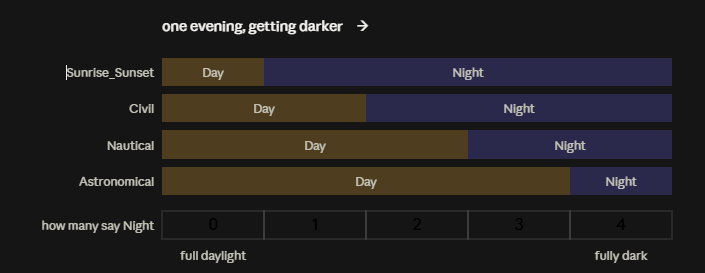

This shows that the bottom row (broken into 5 segments) -look down across columns - 0,1,2,3,4 ( 0 day, 1 - one of the columns show night, 2 - two col show night, 3 --> 4 et. etc.)

build a column which shows the scale from 0-->4

## checkpoint ## save the df as df_temp so that the whole script doesn't need to re-run if the kernal struggles

In [35]:
df.to_csv('../data/df_temp.csv', index = True)

In [109]:
#read csv in
df_temp = pd.read_csv('../data/df_temp.csv')

In [110]:
light_list = ['sunrise_sunset', 'civil_twilight', 'nautical_twilight', 'astronomical_twilight']
df_temp.loc[:, light_list]
#23246 are NaN
# cater for them 



,sunrise_sunset,civil_twilight,nautical_twilight,astronomical_twilight
0,Night,Night,Night,Night
1,Night,Night,Night,Day
2,Night,Night,Day,Day
3,Night,Day,Day,Day
4,Day,Day,Day,Day
...,...,...,...,...
7728389,Day,Day,Day,Day
7728390,Day,Day,Day,Day
7728391,Day,Day,Day,Day
7728392,Day,Day,Day,Day


In [111]:
# now turn day = 0, night = 1
df_temp[light_list] = df_temp[light_list].replace({'Day' :0, 'Night': 1}, regex = False)
    

In [113]:
df_temp[light_list].apply(lambda x: x.value_counts(normalize = True)) #  the proportion of night and day encoded 
# now calculate the sum:
df_temp['light_score'] = df_temp[light_list].sum(axis= 1, skipna = False) # it will keep NA rows if there is even a single one
df_temp['light_score'].unique() # contains 0,1,2,3,4 & NaN

array([4, 3, 2, 1, 0, nan], dtype=object)

In [118]:
 # check the proportion of each score in the ilght_score column 
df_temp.light_score.value_counts(normalize= True, dropna= False)

# cross tabulate with the sunrise_sunset column - they should aggree that any 0 = day as this is the weakest column 
pd.crosstab(df_temp.light_score, df_temp.sunrise_sunset, normalize = True).round(2)

sunrise_sunset,0,1
light_score,,
0,0.69,0.00
1,0.00,0.05
2,0.00,0.05
3,0.00,0.04
4,0.00,0.17


interpret the cross tab table:
    - Astronomical is the strictest — the last of the four light scores to flip & agree its night. 
    
        - So it only says Night when all four say Night, which is exactly light_score= 4.

        - now take all night accidents - 1-0.69 = 0.31 --> OF the 0.31, 0.14 is NOT astronomical_twilight (true dark)

        - therefore: 0.14/0.31 ~ 0.44 = 44% of night accidents happen at twilight 
        

In [94]:
# now that we know there are NaN lets see if its for all the same rows across these columns
light_data_missing = df_temp[df_temp.loc[:, light_list].isna().any(axis=1)]
light_data_missing.isna().sum()
# not only is light missing, preceiptiation is missing, windspeed is missing for some, city is missing, end long, lat,city, windchill,

Unnamed: 0                   0
id                           0
source                       0
severity                     0
start_time                   0
end_time                     0
start_lat                    0
start_lng                    0
end_lat                   1675
end_lng                   1675
distance(mi)                 0
description                  0
street                     177
city                       253
county                       0
state                        0
zipcode                     41
timezone(us)               224
airport_code              2575
weather_timestamp         2744
temperature(f)            2898
wind_chill(f)             3172
humidity(%)               2948
pressure(in)              2862
visibility(mi)            2942
wind_direction            2995
wind_speed(mph)           3010
precipitation(in)         2963
weather_condition         2924
amenity                      0
bump                         0
crossing                     0
give_way

To note:
Start time, end time, weather time stamp - these are not features which are categorical they should be date time stamped.

In [121]:
df_temp.start_time


0          2016-02-08 05:46:00
1          2016-02-08 06:07:59
2          2016-02-08 06:49:27
3          2016-02-08 07:23:34
4          2016-02-08 07:39:07
                  ...         
7728389    2019-08-23 18:03:25
7728390    2019-08-23 19:11:30
7728391    2019-08-23 19:00:21
7728392    2019-08-23 19:00:21
7728393    2019-08-23 18:52:06
Name: start_time, Length: 7728394, dtype: str

In [122]:
df_temp.start_time.dtype
df_temp.end_time.dtype
#both are interpreted as strings - they need to be converted to date time objects then alinged across time zones for uniformity 
df_temp['start_time'] = pd.to_datetime(df_temp['start_time'], format="ISO8601")
df_temp['end_time'] = pd.to_datetime(df_temp['end_time'], format="ISO8601")
df_temp['weather_timestamp'] = pd.to_datetime(df_temp['weather_timestamp'], format="ISO8601")


In [124]:
df_temp['time_delta'] = df_temp.end_time - df_temp.start_time
# convert to seconds 
df_temp['time_delta'] = df_temp['time_delta'].dt.total_seconds()

df_temp['time_delta'].describe(percentiles = [0.5, 0.75, 0.99, 0.9999])
df_temp['time_delta'].skew()
df_temp['time_delta'].kurtosis()
#high kurtosis - outliers are more further out.

np.float64(3659.5997431270503)

In [125]:
df_temp.columns

Index(['Unnamed: 0', 'id', 'source', 'severity', 'start_time', 'end_time',
       'start_lat', 'start_lng', 'end_lat', 'end_lng', 'distance(mi)',
       'description', 'street', 'city', 'county', 'state', 'zipcode',
       'timezone(us)', 'airport_code', 'weather_timestamp', 'temperature(f)',
       'wind_chill(f)', 'humidity(%)', 'pressure(in)', 'visibility(mi)',
       'wind_direction', 'wind_speed(mph)', 'precipitation(in)',
       'weather_condition', 'amenity', 'bump', 'crossing', 'give_way',
       'junction', 'no_exit', 'railway', 'roundabout', 'station', 'stop',
       'traffic_calming', 'traffic_signal', 'sunrise_sunset', 'civil_twilight',
       'nautical_twilight', 'astronomical_twilight', 'light_score',
       'time_delta'],
      dtype='str')

Geographical Features:
street, city, county, state, zipcode, airport_code - cardinality 

In [129]:
geo_features = ['street', 'city', 'county', 'state', 'zipcode', 'airport_code']
df_temp.loc[:, geo_features].apply(lambda x: x.value_counts(normalize = True, dropna = False))

,street,city,county,state,zipcode,airport_code
1 1/2 Ave,5.175720e-07,NaN,NaN,NaN,NaN,NaN
1 Mile Rd,1.293930e-07,NaN,NaN,NaN,NaN,NaN
1-2,1.293930e-07,NaN,NaN,NaN,NaN,NaN
1/2 Ave,4.269969e-06,NaN,NaN,NaN,NaN,NaN
1/2 Ave NW,1.293930e-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
Zygmunt Dr,1.293930e-07,NaN,NaN,NaN,NaN,NaN
de Lee Way,1.293930e-07,NaN,NaN,NaN,NaN,NaN
del Tura Plaza Cir,1.293930e-07,NaN,NaN,NaN,NaN,NaN
william Carey Dr,5.175720e-07,NaN,NaN,NaN,NaN,NaN


Step 2, 3: what is the Column we need to calculate severity in terms of effect on traffic and time delays?
what would you training test, and target features be.
Then get into step 2 - trend and basic analysis; correlations, covariance, scaling, standardisation, visualisatino of feautres with one another. 